In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
import PIL.Image

from dm_control import mjcf
from dm_control import viewer

from swarmbots.unit import Unit
from swarmbots.rendering import display_video

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
RENDER_WIDTH = 640
RENDER_HEIGHT = 480

In [137]:
env = mjcf.RootElement()

getattr(env.visual, 'global').offwidth = RENDER_WIDTH
getattr(env.visual, 'global').offheight = RENDER_HEIGHT

chequered = env.asset.add('texture', type='2d', builtin='checker', width=300,
                            height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = env.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[5, 5], reflectance=.2)
env.worldbody.add('geom', type='plane', size=[2, 2, .1], material=grid)

for x in [-2, 2]:
  env.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])

unit = Unit(0.1, 0.2, 0.025, np.pi/2)

spawn_site = env.worldbody.add('site', pos=[0, 0, 0.5])#, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
spawn_site.attach(unit.model).add('freejoint')
# env.to_xml_string()

# unit = Unit(0.1, 0.2, 0.025, np.pi/2)
# 
# spawn_site = env.worldbody.add('site', pos=[0, 0, 0.2], euler=[0, 109.4712/180*np.pi, 1.05])#, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
# spawn_site.attach(unit.model).add('freejoint')

MJCF Element: <freejoint name="unnamed_model/"/>

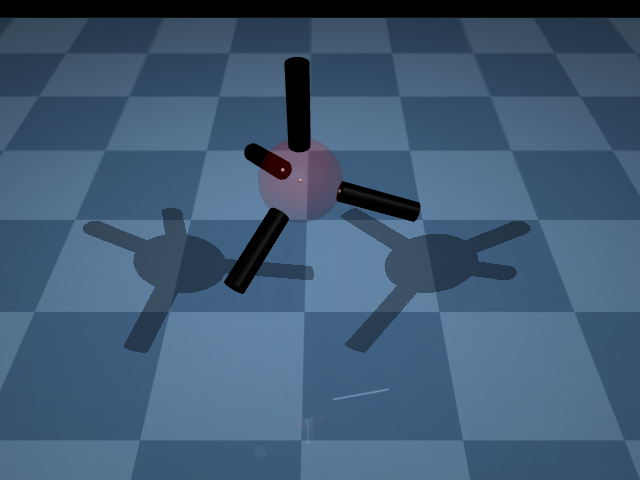

In [135]:
physics = mjcf.Physics.from_mjcf_model(env)
PIL.Image.fromarray(physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT))

In [136]:
duration = 10   # (Seconds)
framerate = 30  # (Hz)
video = []

# Simulate, saving video frames and torso locations.
physics.reset()
while physics.data.time < duration:
  physics.step()

  # Save video frames.
  if len(video) < physics.data.time * framerate:
    pixels = physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT)
    video.append(pixels.copy())

display_video(video, framerate)